# Part 1 Question 1

In [15]:
# Load the data
import polars as pl

data_directory = "data/heart.csv"
data_split_file = "data/splits_heart.csv"

# add row_index column to heart data as it does not have it
# splits_heart.csv uses the row number (row_index)
data = pl.read_csv(data_directory).with_row_index("row_index")
splits = pl.read_csv(data_split_file).with_columns(
    pl.col("row_index").cast(pl.UInt32)
 )
# Attach the split label to every row
data_with_split = data.join(splits, on="row_index", how="left")

# Split into train and test
train_data = data_with_split.filter(pl.col("split") == "train").drop(["row_index", "split"])
test_data = data_with_split.filter(pl.col("split") == "test").drop(["row_index", "split"])


In [24]:
# types of features
print(train_data.describe())


shape: (9, 13)
┌────────────┬───────────┬──────┬─────────────┬───┬─────────────┬──────────┬──────────┬────────────┐
│ statistic  ┆ Age       ┆ Sex  ┆ ChestPainTy ┆ … ┆ ExerciseAng ┆ Oldpeak  ┆ ST_Slope ┆ HeartDisea │
│ ---        ┆ ---       ┆ ---  ┆ pe          ┆   ┆ ina         ┆ ---      ┆ ---      ┆ se         │
│ str        ┆ f64       ┆ str  ┆ ---         ┆   ┆ ---         ┆ f64      ┆ str      ┆ ---        │
│            ┆           ┆      ┆ str         ┆   ┆ str         ┆          ┆          ┆ f64        │
╞════════════╪═══════════╪══════╪═════════════╪═══╪═════════════╪══════════╪══════════╪════════════╡
│ count      ┆ 734.0     ┆ 734  ┆ 734         ┆ … ┆ 734         ┆ 734.0    ┆ 734      ┆ 734.0      │
│ null_count ┆ 0.0       ┆ 0    ┆ 0           ┆ … ┆ 0           ┆ 0.0      ┆ 0        ┆ 0.0        │
│ mean       ┆ 53.848774 ┆ null ┆ null        ┆ … ┆ null        ┆ 0.865123 ┆ null     ┆ 0.553134   │
│ std        ┆ 9.440574  ┆ null ┆ null        ┆ … ┆ null        ┆ 1.056964 ┆

In [38]:
#total number of missing values
missing_values = train_data.select(pl.all().null_count())
# total_missing_values = sum(missing_values.values())
missing_values
# print(f"total amount of missing values in train_data: {missing_values.values()[0]}")


Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0


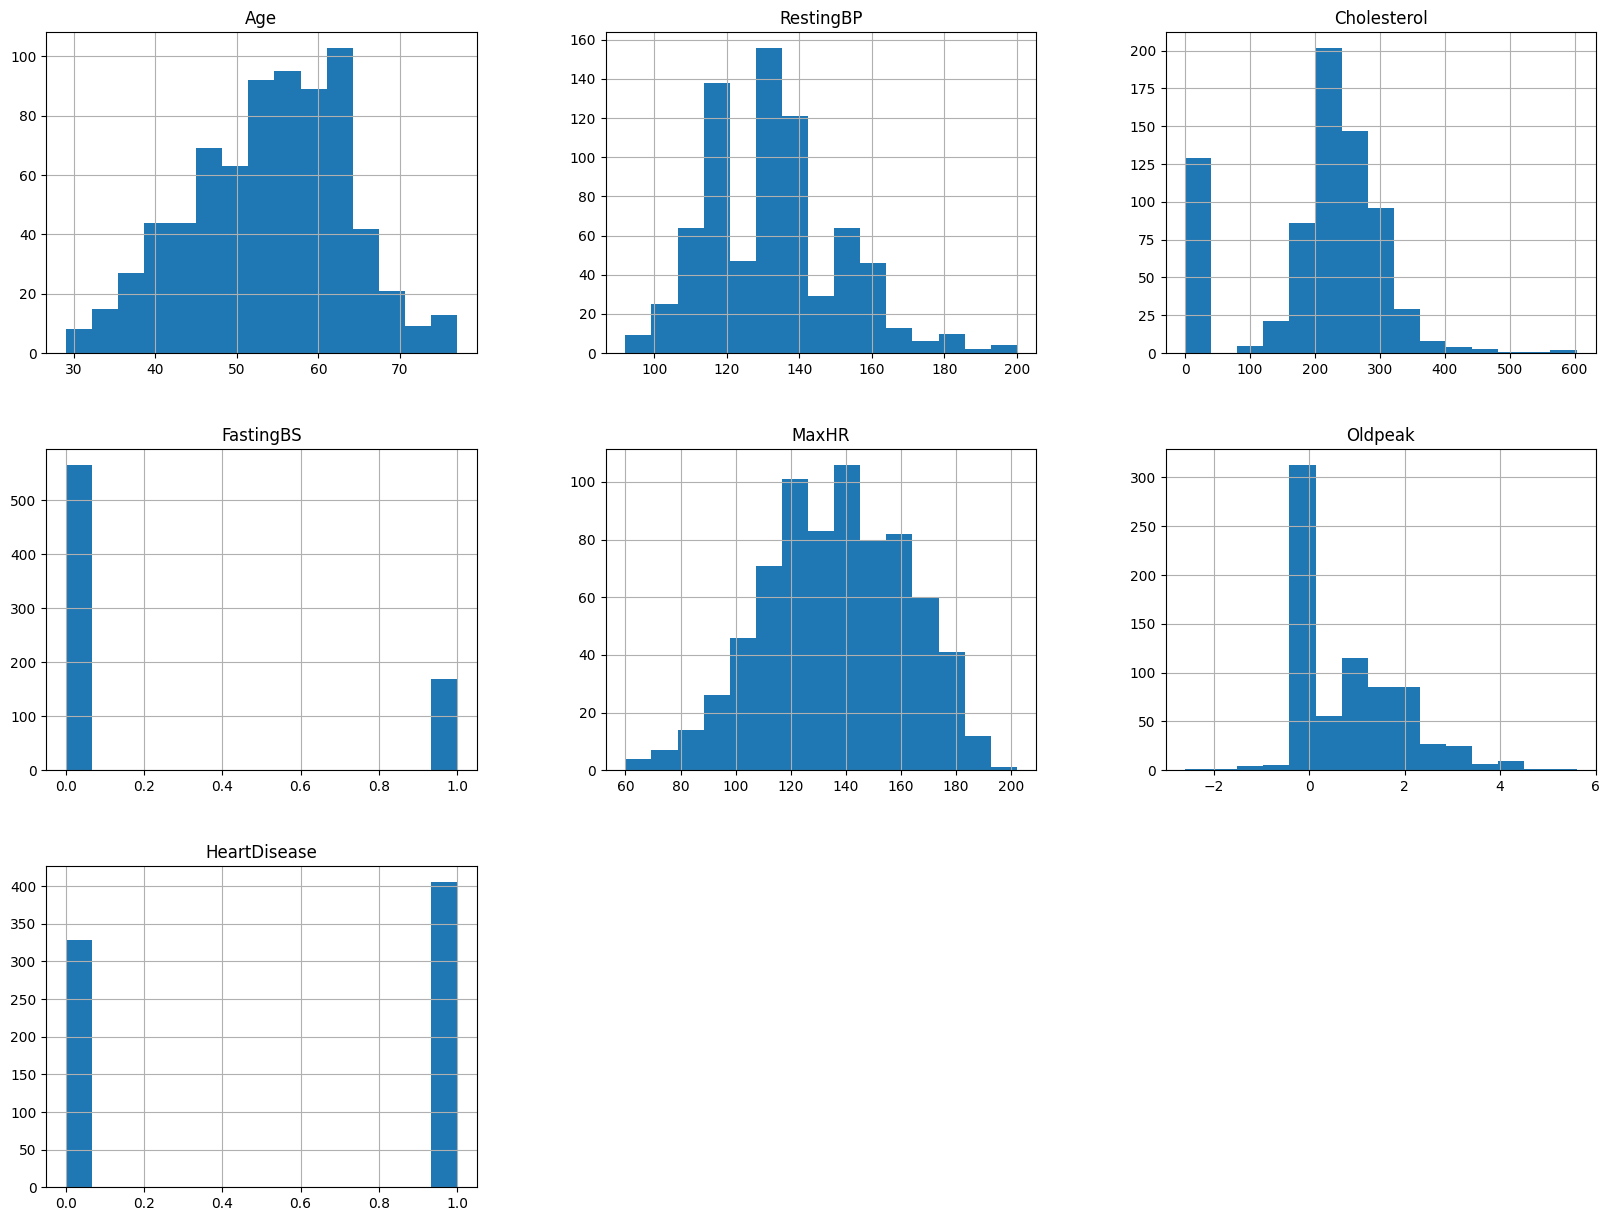

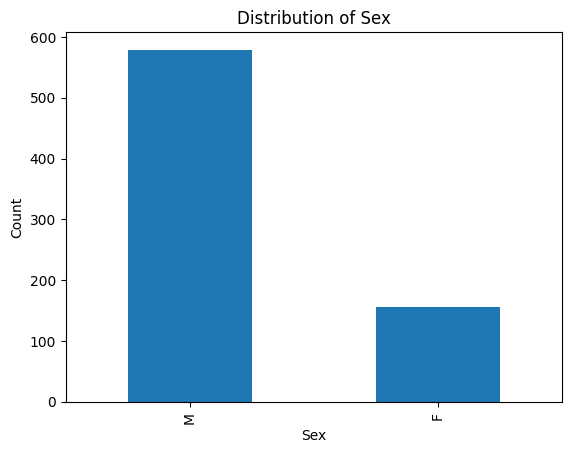

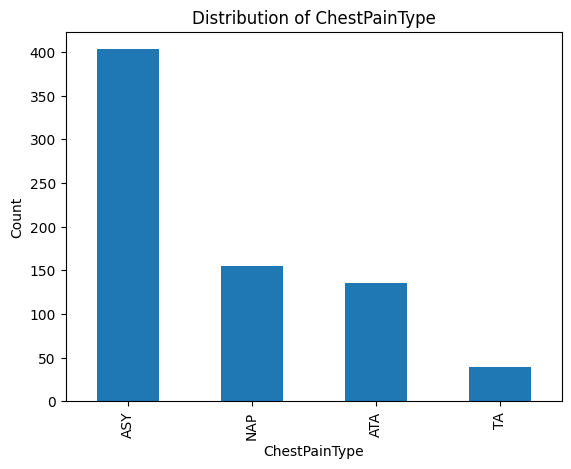

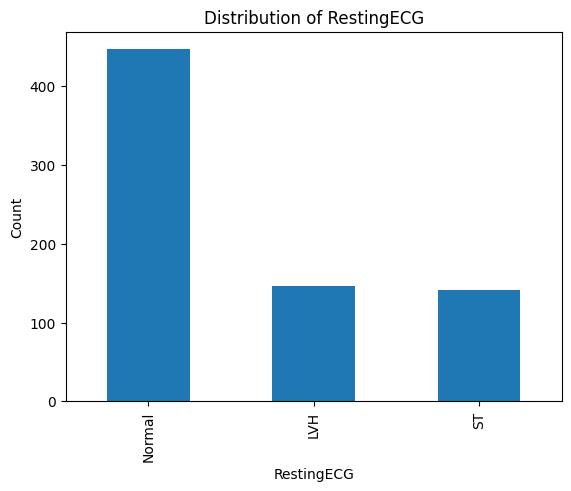

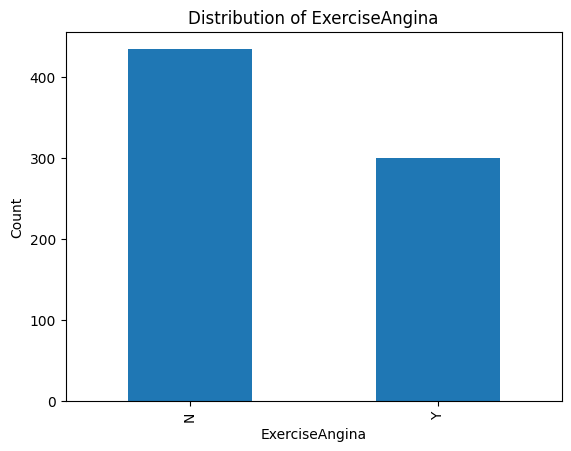

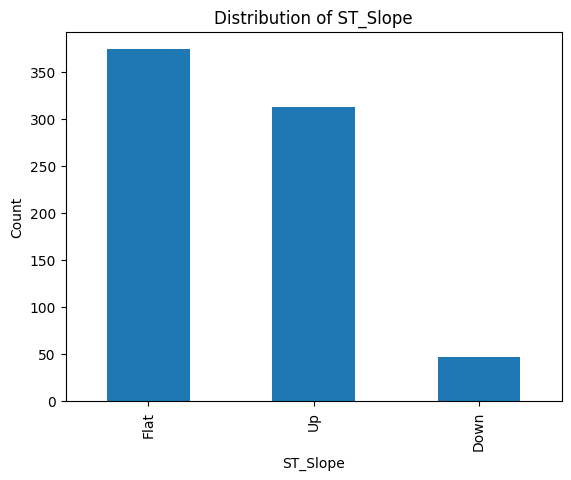

In [40]:
#distrubtion of the features
import matplotlib.pyplot as plt
import pandas as pd
train_data_df = train_data.to_pandas()
train_data_df.hist(bins=15, figsize=(20,15))
plt.show()
#bar charts for categorical features
categorical_features = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina","ST_Slope"]
for feature in categorical_features:
    train_data_df[feature].value_counts().plot(kind='bar')
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.show()

## Exploring the features (train split)

For the training data we observed the following:
- `Age`: Looks approximately normal with mean around 55.
- `Sex`: Imbalanced; about ~80% male and ~20% female.
- `ChestPainType`: 4 categories (`ASY`, `NAP`, `ATA`, `TA`); `ASY` (asymptomatic) is most common and `TA` is rare.
- `RestingBP`: Most values are around ~110–140, with a few higher outliers (up to ~200).
- `Cholesterol`: Noticeable spike at `0` for some patients. Otherwise mostly around ~180–320 with a long right tail (up to ~600).
- `FastingBS`: Binary (0/1); mostly `0`, with a smaller fraction (≈20–25%) being `1`.
- `RestingECG`: 3 categories (`Normal`, `LVH`, `ST`); `Normal` dominates, while `LVH` and `ST` are much less frequent.
- `MaxHR`: Broad spread (~60–200), with most values around ~110–170.
- `ExerciseAngina`: Binary (`N`/`Y`); more `N` than `Y`.
- `Oldpeak`: Many values exactly `0`; most are between 0–2, with some negative values and a right tail up to ~6.
- `ST_Slope`: 3 categories (`Flat`, `Up`, `Down`); `Flat` is most common, `Down` is rare.
- `HeartDisease` (label): Binary (0/1); slightly more `1`s than `0`s (mild class imbalance).


Look more into sex and the relation to the response variable, as there might some different outcomes for the different sexes.
Look more into if chestpain type can explain a lot of the heartdisease

## Data processing for task 1

In [48]:
# fill in the missing values for cholesterol (rows with value of 0)
# we use KKN nearest neighbors to impute the missing values (fitted only on training data)
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer

# 1. Split into features and target
X_train = train_data_df.drop(columns=["HeartDisease"])
y_train = train_data_df["HeartDisease"]

X_test = test_data_df.drop(columns=["HeartDisease"])
y_test = test_data_df["HeartDisease"]

# 2. Convert categorical text columns to one-hot encoded columns
# We use drop_first=True to avoid multi-collinearity
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# 3. Replace 0 in Cholesterol with np.nan in BOTH sets
X_train["Cholesterol"] = X_train["Cholesterol"].replace(0, np.nan)
X_test["Cholesterol"] = X_test["Cholesterol"].replace(0, np.nan)

# 4. Initialize the KNN Imputer
imputer = KNNImputer(n_neighbors=5)

# 5. FIT on training data, and TRANSFORM training data
train_data_imputed = imputer.fit_transform(X_train)

# 6. ONLY TRANSFORM test data (using rules learned from training)
test_data_imputed = imputer.transform(X_test)

# 7. Convert the raw arrays back into pandas DataFrames with their column names
X_train_clean = pd.DataFrame(train_data_imputed, columns=X_train.columns)
X_test_clean = pd.DataFrame(test_data_imputed, columns=X_test.columns)


#### Distribution of cholesterol

Text(0.5, 1.0, 'Distribution of Cholesterol after Imputation')

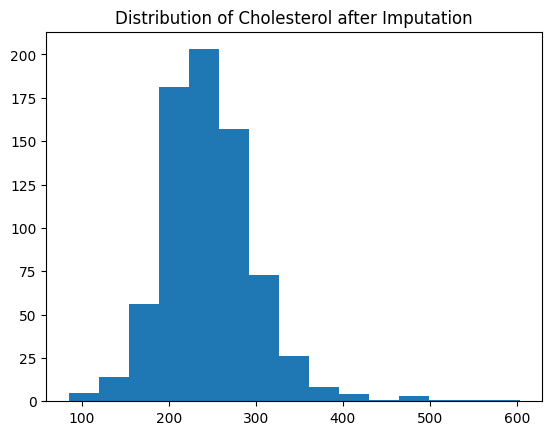

In [47]:
#create a graph showing the distribution of the imputed values for cholesterol
plt.hist(X_train_clean["Cholesterol"], bins=15, label="Train")
plt.title("Distribution of Cholesterol after Imputation")